<a href="https://colab.research.google.com/github/KCCalder/MIR-Cetacean-Calls/blob/main/MIR_Cetacean_Calls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mir_eval

import librosa
import mir_eval
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp
import os
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import seaborn as sns
from sklearn.metrics import confusion_matrix
import soundfile as sf

In [18]:
# Load all .wav files from a folder, returns signals and sample rate
def load_from_folder(folder_path):
  audio_clips = []
  sample_rates = []

  for file in os.listdir(folder_path):
    if file.endswith(".wav"):
        file_path = os.path.join(folder_path, file)
        y, sr = librosa.load(file_path, sr=None)
        audio_clips.append(y)
        sample_rates.append(sr)
  return audio_clips, sample_rates

# Spectral gating noise reduction
def spectral_gate(signal, sr, threshold=1.5):
    d = librosa.stft(signal)
    S, phase = np.abs(d), np.angle(d)

    # Find mean amplitude for each freq, create mask when not meaningfully "above" that value
    noise_profile = np.median(S, axis=1, keepdims=True)
    mask = S > threshold * noise_profile
    S_denoised = S * mask
    d_denoised = S_denoised * np.exp(1j * phase)

    sig_clean = librosa.istft(d_denoised)

    return sig_clean

# Spectral subtraction noise reduction
def spectral_subtraction(signal, sr, alpha=2.0, beta=0.02, dur=0.3):
    d = librosa.stft(signal)
    mag, phase = librosa.magphase(d)
    power = mag**2

    noise_frames = int(librosa.time_to_frames(dur, sr=sr))
    noise_est = np.mean(power[:, :noise_frames], axis=1, keepdims=True)

    power_clean = power - (alpha * noise_est)

    power_clean = np.maximum(power_clean, beta * noise_est)

    # Reconstruct the signal
    mag_clean = np.sqrt(power_clean)
    stft_clean = mag_clean * phase
    sig_clean = librosa.istft(stft_clean)

    return sig_clean

# Take set of signals and convert all into spectrograms (Db)
def wav_to_spectrogram(signals, sr):
  spectrograms = []
  for i in range(len(signals)):
    spectrogram = librosa.feature.melspectrogram(y=signals[i], sr=sr[i])
    spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    spectrograms.append(spectrogram)
  return spectrograms

def wav_to_spectrogram_pcen(signals, sr):
  spectrograms = []
  for i in range(len(signals)):
    spectrogram = librosa.feature.melspectrogram(y=signals[i], sr=sr[i], power=1, n_mels=128)
    spectrogram = librosa.pcen(spectrogram, sr=sr[i])
    spectrograms.append(spectrogram)
  return spectrograms

In [6]:
# Data folder paths (change to appropriate)
srkw_path = "/content/drive/MyDrive/Orchive Project/SRKW"
humpback_path = "/content/drive/MyDrive/Orchive Project/Humpback"
negative_path = "/content/drive/MyDrive/Orchive Project/Negative"

# Load in the training data (may take a while ~2-3 min)
srkw_clips, srkw_sr = load_from_folder(srkw_path)
humpback_clips, humpback_sr = load_from_folder(humpback_path)
negative_clips, negative_sr = load_from_folder(negative_path)

# Shuffle clips
np.random.seed(42) # For reproducability
np.random.shuffle(srkw_clips)
np.random.shuffle(humpback_clips)
np.random.shuffle(negative_clips)

In [8]:
# Convert to mel spectrograms
srkw_spectrograms = wav_to_spectrogram(srkw_clips, srkw_sr)
humpback_spectrograms = wav_to_spectrogram(humpback_clips, humpback_sr)
negative_spectrograms = wav_to_spectrogram(negative_clips, negative_sr)

# Test train split
te_spectrograms = np.concatenate((srkw_spectrograms[-100:], humpback_spectrograms[-100:], negative_spectrograms[-100:]), axis=0)
te_spectrograms = np.expand_dims(te_spectrograms, axis=-1)
te_labels = np.concatenate((np.ones(100), np.ones(100) * 2, np.zeros(100)), axis=None)
te_labels.reshape(-1, 1)

# Create labels array
tr_labels = np.concatenate((np.ones(600), np.ones(600) * 2, np.zeros(600)), axis=None)
tr_labels.reshape(-1, 1)

# Combine the spectrogram plots
tr_spectrograms = np.concatenate((srkw_spectrograms[:600], humpback_spectrograms[:600], negative_spectrograms[:600]), axis=0)
tr_spectrograms = np.expand_dims(tr_spectrograms, axis=-1)

In [23]:
# Baseline CNN (trained on raw spectrograms)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model = models.Sequential([
    layers.Input(shape=(128, 376, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(tr_spectrograms, tr_labels, epochs=25,
                    validation_data=(te_spectrograms, te_labels),
                    shuffle=True, callbacks=[early_stopping])


Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.5017 - loss: 1.0250 - val_accuracy: 0.3267 - val_loss: 2.0066
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.5911 - loss: 0.8812 - val_accuracy: 0.2500 - val_loss: 1.2895
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.6444 - loss: 0.8107 - val_accuracy: 0.5533 - val_loss: 0.9595
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.6622 - loss: 0.7655 - val_accuracy: 0.5067 - val_loss: 1.0291
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.6900 - loss: 0.7083 - val_accuracy: 0.5700 - val_loss: 0.8293
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.7178 - loss: 0.6492 - val_accuracy: 0.6900 - val_loss: 0.7696
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.7339 - loss: 0.6185 - val_accuracy: 0.4467 - val_loss: 1.2872
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.7694 - loss: 0.5835 - val_accuracy: 0.6233 - v

10/10 - 6s - 588ms/step - accuracy: 0.7667 - loss: 0.4957


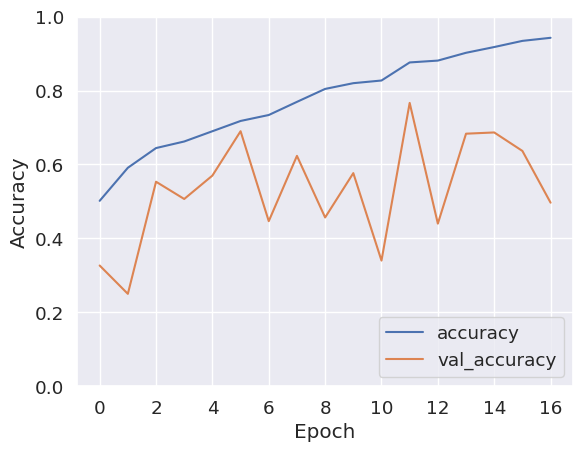

In [24]:
# Accuracy plot for raw CNN

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(te_spectrograms,  te_labels, verbose=2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 551ms/step


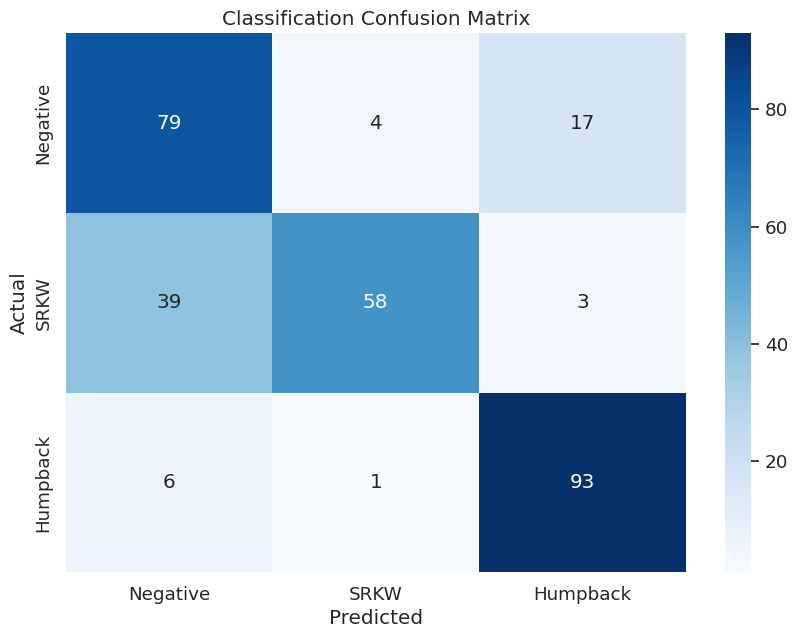

In [25]:
#Confusion Matrix for Raw CNN

predictions = model.predict(te_spectrograms)

# Label based on highest prob
y_pred = np.argmax(predictions, axis=1)

y_true = te_labels
class_names = ['Negative', 'SRKW', 'Humpback'] # 0 = Negative, 1 = SRKW, 2 = Humpback

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)


# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [21]:
# Data prep for PCEN CNN

# Apply PCEN to training spectrograms
pcen_tr = []
for i in range(len(tr_spectrograms)):
  pow_spectrogram = librosa.db_to_power(tr_spectrograms[i], ref=1.0)
  pcen_tr.append(librosa.pcen(pow_spectrogram, sr=srkw_sr[0]))
pcen_tr = np.array(pcen_tr)

# Apply PCEN to testing spectrograms
pcen_te = []
for i in range(len(te_spectrograms)):
  pow_spectrogram = librosa.db_to_power(te_spectrograms[i], ref=1.0)
  pcen_te.append(librosa.pcen(pow_spectrogram, sr=srkw_sr[0]))
pcen_te = np.array(pcen_te)

# Normalize (values between 0 and 1)
pcen_min = pcen_tr.min()
pcen_max = pcen_tr.max()
pcen_tr = (pcen_tr - pcen_min) / (pcen_max - pcen_min)
pcen_te = (pcen_te - pcen_min) / (pcen_max - pcen_min)

In [37]:
# PCEN CNN

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

pcen_model = models.Sequential([
    layers.Input(shape=(128, 376, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3)
])

pcen_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

pcen_history = pcen_model.fit(pcen_tr, tr_labels, epochs=25,
                    validation_data=(pcen_te, te_labels),
                    shuffle=True, callbacks=[early_stopping])

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.4461 - loss: 5.2263 - val_accuracy: 0.3500 - val_loss: 1.4980
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.5250 - loss: 1.0975 - val_accuracy: 0.3667 - val_loss: 1.0961
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.5161 - loss: 1.0556 - val_accuracy: 0.3600 - val_loss: 1.1006
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.5267 - loss: 1.0127 - val_accuracy: 0.3667 - val_loss: 1.0771
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.5322 - loss: 1.1063 - val_accuracy: 0.3667 - val_loss: 3.2633
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.5278 - loss: 0.9743 - val_accuracy: 0.3733 - val_loss: 1.6645
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step - accuracy: 0.5378 - loss: 1.1090 - val_accuracy: 0.4633 - val_loss: 0.9176
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step - accuracy: 0.5628 - loss: 0.8691 - val_accuracy: 0.5333 - v

10/10 - 8s - 798ms/step - accuracy: 0.6367 - loss: 0.7464


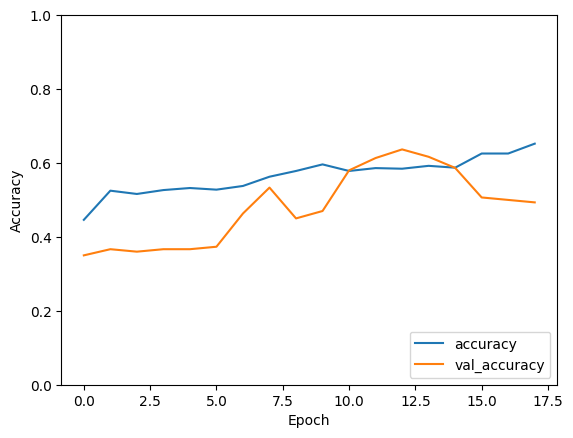

In [38]:
# Accuracy plot for PCEN

plt.plot(pcen_history.history['accuracy'], label='accuracy')
plt.plot(pcen_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = pcen_model.evaluate(pcen_te,  te_labels, verbose=2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


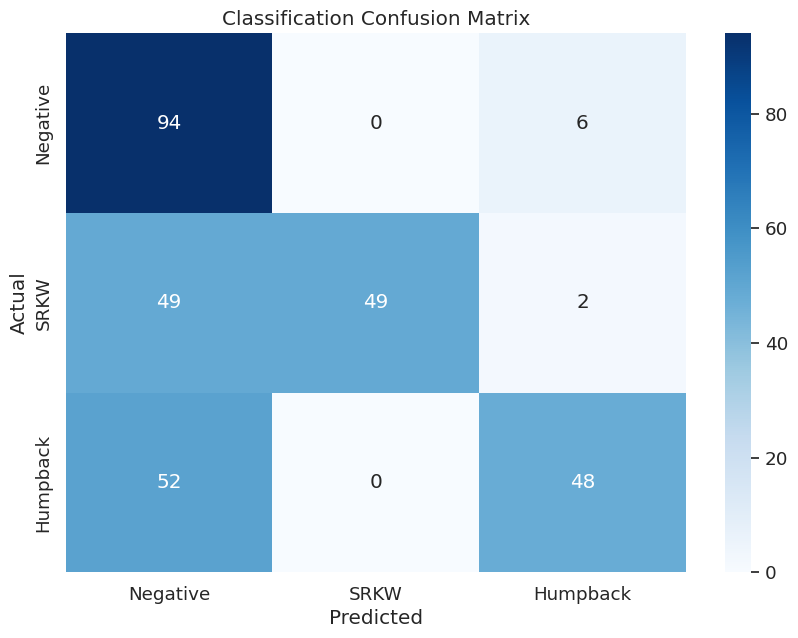

In [39]:
# Confusion Matrix for CNN

predictions = pcen_model.predict(pcen_te)

# Label based on highest prob
y_pred = np.argmax(predictions, axis=1)

y_true = te_labels
class_names = ['Negative', 'SRKW', 'Humpback'] # 0 = Negative, 1 = SRKW, 2 = Humpback

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)


# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2) # Adjust font size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [40]:
# Spectral Subtraction samples set up
srkw_sub_clips = []
humpback_sub_clips = []
negative_sub_clips = []
for i in range(len(srkw_clips)):
  srkw_sub_clips.append(spectral_subtraction(srkw_clips[i], srkw_sr[i]))
  humpback_sub_clips.append(spectral_subtraction(humpback_clips[i], humpback_sr[i]))
  negative_sub_clips.append(spectral_subtraction(negative_clips[i], negative_sr[i]))

srkw_sub_clips = np.array(srkw_sub_clips)
humpback_sub_clips = np.array(humpback_sub_clips)
negative_sub_clips = np.array(negative_sub_clips)

# Convert to mel spectrograms
srkw_sub_spectrograms = wav_to_spectrogram(srkw_clips, srkw_sr)
humpback_sub_spectrograms = wav_to_spectrogram(humpback_clips, humpback_sr)
negative_sub_spectrograms = wav_to_spectrogram(negative_clips, negative_sr)

# Test train split
te_sub_spectrograms = np.concatenate((srkw_sub_spectrograms[-100:], humpback_sub_spectrograms[-100:], negative_sub_spectrograms[-100:]), axis=0)
te_sub_spectrograms = np.expand_dims(te_sub_spectrograms, axis=-1)
te_labels = np.concatenate((np.ones(100), np.ones(100) * 2, np.zeros(100)), axis=None)
te_labels.reshape(-1, 1)

# Create labels array
tr_labels = np.concatenate((np.ones(600), np.ones(600) * 2, np.zeros(600)), axis=None)
tr_labels.reshape(-1, 1)

# Combine the spectrogram plots
tr_sub_spectrograms = np.concatenate((srkw_sub_spectrograms[:600], humpback_sub_spectrograms[:600], negative_sub_spectrograms[:600]), axis=0)
tr_sub_spectrograms = np.expand_dims(tr_sub_spectrograms, axis=-1)

In [26]:
# Spectral subtraction CNN

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

sub_model = models.Sequential([
    layers.Input(shape=(128, 376, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3)
])

sub_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

sub_history = sub_model.fit(tr_sub_spectrograms, tr_labels, epochs=25,
                    validation_data=(te_sub_spectrograms, te_labels),
                    shuffle=True, callbacks=[early_stopping])

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.5256 - loss: 0.9886 - val_accuracy: 0.3033 - val_loss: 2.4327
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 265s 4s/step - accuracy: 0.6183 - loss: 0.8602 - val_accuracy: 0.2267 - val_loss: 1.4403
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.6272 - loss: 0.8069 - val_accuracy: 0.4100 - val_loss: 1.1015
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.6633 - loss: 0.7507 - val_accuracy: 0.6000 - val_loss: 0.8929
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.6767 - loss: 0.7063 - val_accuracy: 0.6900 - val_loss: 0.7531
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.6817 - loss: 0.6940 - val_accuracy: 0.4000 - val_loss: 1.3190
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.7189 - loss: 0.6434 - val_accuracy: 0.6633 - val_loss: 0.7028
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.7528 - loss: 0.5900 - val_accuracy: 0.6067 - v

10/10 - 7s - 727ms/step - accuracy: 0.9300 - loss: 0.2424


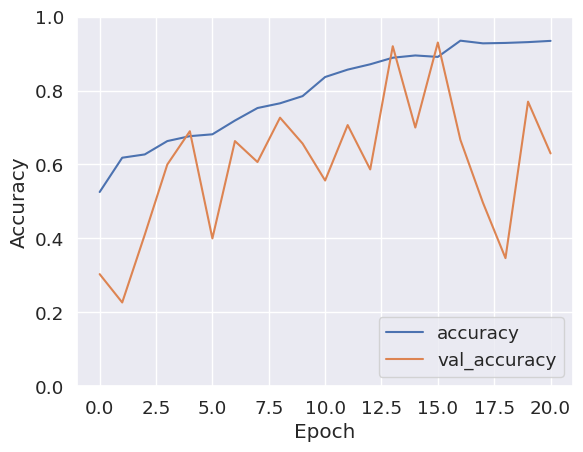

In [27]:
# Spectral Subtraction Accuracy Plot

plt.plot(sub_history.history['accuracy'], label='accuracy')
plt.plot(sub_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = sub_model.evaluate(te_sub_spectrograms,  te_labels, verbose=2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 549ms/step


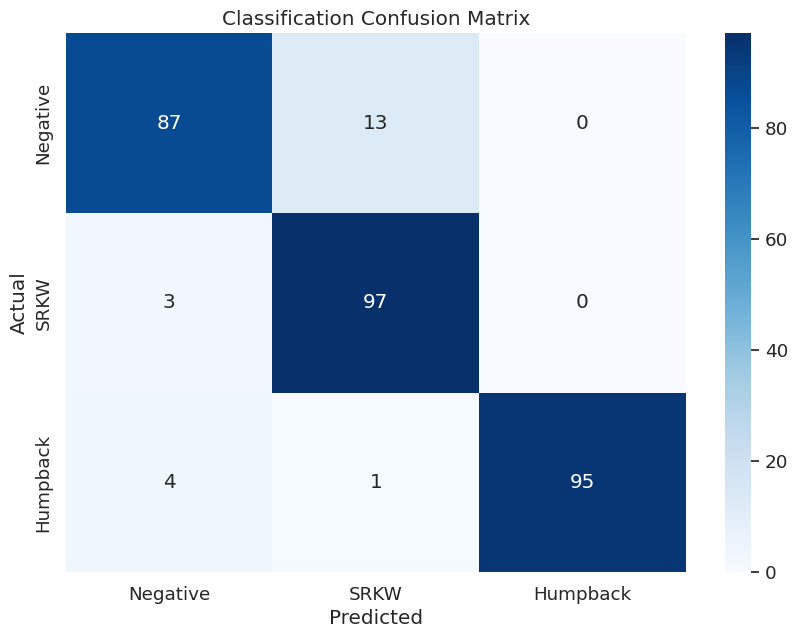

In [28]:
#Spectral Subtraction Confusion Matrix

predictions = sub_model.predict(te_sub_spectrograms)

# Label based on highest prob
y_pred = np.argmax(predictions, axis=1)

y_true = te_labels
class_names = ['Negative', 'SRKW', 'Humpback'] # 0 = Negative, 1 = SRKW, 2 = Humpback

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)


# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2) # Adjust font size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Demos showcasing the different denoising algorithms

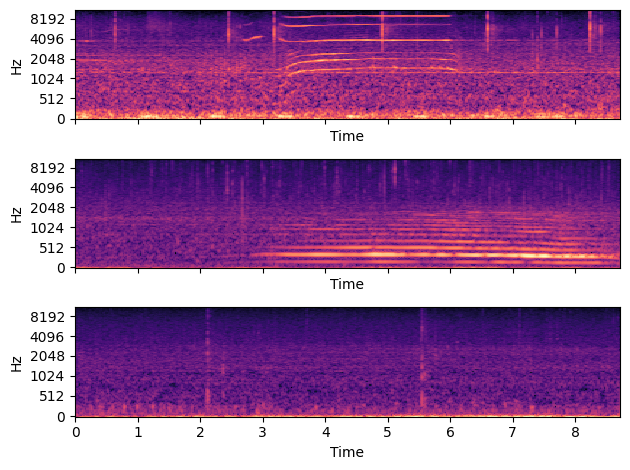

In [35]:
fig, ax = plt.subplots(nrows=3, sharex=True)

# Example of a SRKW spectrogram
ex_srkw_plot = librosa.feature.melspectrogram(y=srkw_clips[10], sr=srkw_sr[10])
librosa.display.specshow(librosa.power_to_db(ex_srkw_plot, ref=np.max), y_axis='mel', x_axis='time', ax=ax[0])

# Example of a Humpback spectrogram
ex_humpback_plot = librosa.feature.melspectrogram(y=humpback_clips[2], sr=humpback_sr[2])
librosa.display.specshow(librosa.power_to_db(ex_humpback_plot, ref=np.max), y_axis='mel', x_axis='time', ax=ax[1])

# Example of a Negative spectrogram
ex_negative_plot = librosa.feature.melspectrogram(y=negative_clips[1], sr=negative_sr[1])
librosa.display.specshow(librosa.power_to_db(ex_negative_plot, ref=np.max), y_axis='mel', x_axis='time', ax=ax[2])

plt.tight_layout()

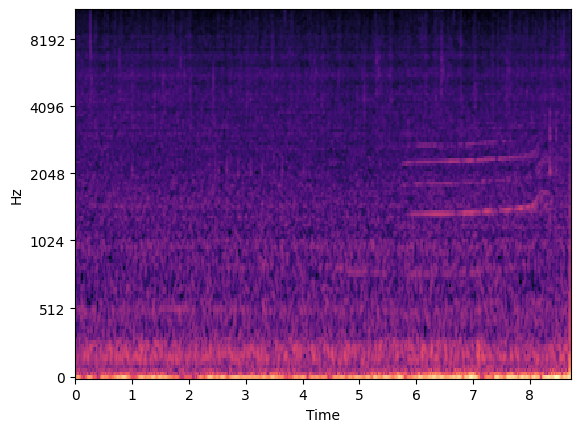

In [15]:
# Raw Spectrogram and Audio

srkw_plot = librosa.feature.melspectrogram(y=srkw_clips[2], sr=srkw_sr[2])
librosa.display.specshow(librosa.power_to_db(srkw_plot, ref=np.max), y_axis='mel', x_axis='time')

ipd.Audio(srkw_clips[2], rate=srkw_sr[2])

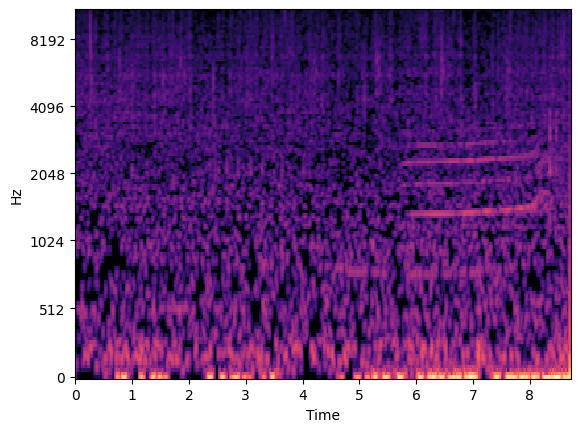

In [18]:
# Spectral Gate spectrogram and audio

denoise_srkw = spectral_gate(srkw_clips[2], srkw_sr[2], threshold=1.5)

denoise_humpback = spectral_gate(humpback_clips[5], humpback_sr[0], threshold=1.5)

denoise_srkw_plot = librosa.feature.melspectrogram(y=denoise_srkw, sr=srkw_sr[16])
librosa.display.specshow(librosa.power_to_db(denoise_srkw_plot, ref=np.max), y_axis='mel', x_axis='time')

ipd.Audio(denoise_srkw, rate=srkw_sr[0])

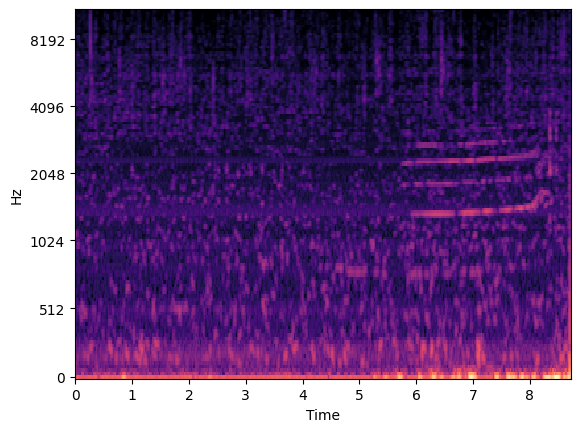

In [17]:
# Spectral Subtraction spectrogram and audio

spec_sub_srkw = spectral_subtraction(srkw_clips[2], srkw_sr[2])

spec_sub_srkw_plot = librosa.feature.melspectrogram(y=spec_sub_srkw, sr=srkw_sr[2])
librosa.display.specshow(librosa.power_to_db(spec_sub_srkw_plot, ref=np.max), y_axis='mel', x_axis='time')

ipd.Audio(spec_sub_srkw, rate=srkw_sr[2])

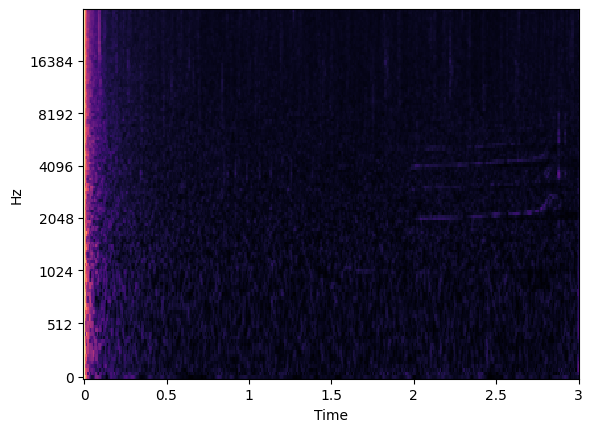

In [25]:
# PCEN spectrogram (no audio)

base_srkw = librosa.feature.melspectrogram(y=srkw_clips[2], sr=srkw_sr[2], power=1, n_mels=128)
pcen_srkw = librosa.pcen(base_srkw * (2**31), sr=srkw_sr[2])

librosa.display.specshow(pcen_srkw, y_axis='mel', x_axis='time', sr=srkw_sr[2])